In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CSV_DIR = '/content/drive/MyDrive/SmartSite/Step 1: Extract/Results_CSV'
all_files = glob.glob(os.path.join(CSV_DIR, "*.csv"))

print(f"Tìm thấy {len(all_files)} file CSV trong thư mục.")

Tìm thấy 3 file CSV trong thư mục.


**XỬ LÝ TỔNG QUAN DATA**

In [4]:
df_list = []

for file in all_files:
    filename = os.path.basename(file)
    try:
        if 'HaNoi' in filename:
            df = pd.read_csv(file, sep=';', decimal=',', encoding='utf-8-sig')
            df['City'] = 'HaNoi'

        elif 'HCM' in filename:
            df = pd.read_csv(file, encoding='utf-8-sig')
            df['City'] = 'HCM'

        elif 'DaNang' in filename or 'danang' in filename.lower():
            df = pd.read_csv(file, encoding='utf-8-sig')
            df['City'] = 'DaNang'

        else:
            df = pd.read_csv(file, encoding='utf-8-sig')
            df['City'] = 'Other'

        df_list.append(df)
        print(f"✅ Đã đọc thành công file: {filename}")

    except Exception as e:
        print(f"❌ Lỗi khi đọc file {filename}: {e}")

raw_df = pd.concat(df_list, ignore_index=True)

print("\n" + "="*50)
print(f"TỔNG QUAN DỮ LIỆU THÔ (RAW DATA)")
print("="*50)
print(f"Tổng số dòng (quán): {raw_df.shape[0]}")
print(f"Tổng số cột: {raw_df.shape[1]}")
print("\n📍 Phân bổ theo thành phố:")
print(raw_df['City'].value_counts())

raw_df.head(5)

✅ Đã đọc thành công file: DaNang_GGMap.csv
✅ Đã đọc thành công file: HaNoi_GGMap.csv
✅ Đã đọc thành công file: HCM_GGMap.csv

TỔNG QUAN DỮ LIỆU THÔ (RAW DATA)
Tổng số dòng (quán): 16938
Tổng số cột: 16

📍 Phân bổ theo thành phố:
City
HCM       7641
HaNoi     7534
DaNang    1763
Name: count, dtype: int64


,name,address,phone,category,rating,reviews_count,status,opening_hours,sample_reviews,lat,lng,grid_lat,grid_lng,google_url,place_id,City
0,Tiệm cafe Túi Thương Nhớ,"34J5+85C, Hoà Liên, Hòa Vang, Đà Nẵng, Vietnam",+84 935 345 055,Coffee shop,4.8,122,Open,NaN,"[4 sao] No Air-conditioner coffee, lovely gard...",16.080795,108.107852,16.06,108.105,https://www.google.com/maps/place/Ti%E1%BB%87m...,0x31421f7757209fe1:0x4fd0e3dc4d9f7e1c,DaNang
1,Tiệm cà phê Trần,"97 Nguyễn Lương Bằng/34 Nguyễn Lương Bằng, Ho...",NaN,Coffee shop,4.7,7,Open,NaN,"[5 sao] The owner is friendly, the space is cl...",16.074570,108.148133,16.06,108.105,https://www.google.com/maps/place/Ti%E1%BB%87m...,0x3142190ba98c9787:0xc7f4e1a49fffdedc,DaNang
2,Tiệm Cà Phê Tháng Mười Hai,"72 Nguyễn Chánh, Hoà Khánh Bắc, Liên Chiểu, Đ...",+84 932 454 800,Coffee shop,4.7,36,Open,NaN,[5 sao] Cozy café with great vibes and friendl...,16.083348,108.149781,16.06,108.105,https://www.google.com/maps/place/Ti%E1%BB%87m...,0x3142190007266fb3:0xa9a76ada2e3cbea0,DaNang
3,Tiệm Cà Phê Thời Thanh Xuân,"24J5+FRW, Hoà Sơn, Hòa Vang, Đà Nẵng, Vietnam",+84 935 025 225,Coffee shop,4.5,44,Open,NaN,"[5 sao] Delicious drinks, enthusiastic staff, ...",16.031229,108.109591,16.06,108.105,https://www.google.com/maps/place/Ti%E1%BB%87m...,0x31421f80d2e877c1:0x692363a0b0d00cba,DaNang
4,THE POWERHOUSE 2 COFFEE & MORE,"17 Âu Cơ, Hoà Khánh Bắc, Liên Chiểu, Đà Nẵng ...",+84 966 020 246,Cafe,4.6,359,Open,NaN,[5 sao] Good music\r\nFeel relax || [5 sao] Lo...,16.071301,108.149841,16.06,108.105,https://www.google.com/maps/place/THE+POWERHOU...,0x314219ba642b7693:0xcb5df3470db93a7,DaNang


In [5]:
print(f"Số dòng ban đầu: {raw_df.shape[0]}")

# 1. Khử trùng lặp (Deduplication)
df_clean = raw_df.drop_duplicates(subset=['place_id'], keep='first').copy()
print(f"📉 Sau khi xóa trùng lặp: {df_clean.shape[0]} dòng")

# 2. Xóa Missing Values
df_clean = df_clean.dropna(subset=['lat', 'lng'])
print(f"📉 Sau khi xóa quán thiếu tọa độ: {df_clean.shape[0]} dòng")

# 3. Ép kiểu dữ liệu
df_clean['reviews_count'] = df_clean['reviews_count'].astype(str).str.replace(r'\D', '', regex=True)
df_clean['reviews_count'] = pd.to_numeric(df_clean['reviews_count'], errors='coerce').fillna(0).astype(int)

df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

# 4. Lọc nhiễu (Noise Removal)
df_clean = df_clean[df_clean['reviews_count'] >= 5]
print(f"📉 Sau khi lọc quán < 5 đánh giá: {df_clean.shape[0]} dòng")

# 5. Xử lý NaN cho các cột Text
df_clean['sample_reviews'] = df_clean['sample_reviews'].fillna("")
df_clean['opening_hours'] = df_clean['opening_hours'].fillna("Unknown")

# 6. Dọn dẹp ký tự rác trong cột address, phone (nếu có)
df_clean['address'] = df_clean['address'].astype(str).str.replace(r'^[^a-zA-Z0-9]+', '', regex=True)
df_clean['phone'] = df_clean['phone'].astype(str).str.replace(r'^[^a-zA-Z0-9]+', '', regex=True)

print(f"Tổng số quán HỢP LỆ VÀ SẠCH: {df_clean.shape[0]}")
print("\nPhân bổ Tinh Hoa theo thành phố:")
print(df_clean['City'].value_counts())

df_clean[['name', 'rating', 'reviews_count', 'lat', 'lng', 'City']].head()

Số dòng ban đầu: 16938
📉 Sau khi xóa trùng lặp: 14513 dòng
📉 Sau khi xóa quán thiếu tọa độ: 14513 dòng
📉 Sau khi lọc quán < 5 đánh giá: 8647 dòng
Tổng số quán HỢP LỆ VÀ SẠCH: 8647

Phân bổ Tinh Hoa theo thành phố:
City
HCM       4081
HaNoi     3685
DaNang     881
Name: count, dtype: int64


,name,rating,reviews_count,lat,lng,City
0,Tiệm cafe Túi Thương Nhớ,4.8,122,16.080795,108.107852,DaNang
1,Tiệm cà phê Trần,4.7,7,16.074570,108.148133,DaNang
2,Tiệm Cà Phê Tháng Mười Hai,4.7,36,16.083348,108.149781,DaNang
3,Tiệm Cà Phê Thời Thanh Xuân,4.5,44,16.031229,108.109591,DaNang
4,THE POWERHOUSE 2 COFFEE & MORE,4.6,359,16.071301,108.149841,DaNang


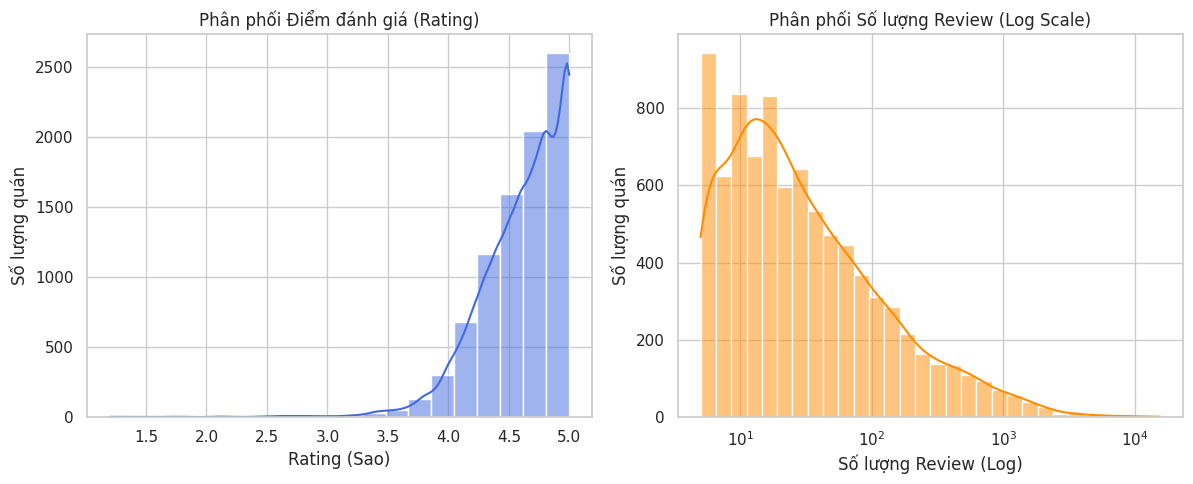

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# Biểu đồ 1: Phân phối Rating
plt.subplot(1, 3, 1)
sns.histplot(df_clean['rating'], bins=20, kde=True, color='royalblue')
plt.title('Phân phối Điểm đánh giá (Rating)')
plt.xlabel('Rating (Sao)')
plt.ylabel('Số lượng quán')

# Biểu đồ 2: Phân phối Review Count
plt.subplot(1, 3, 2)
sns.histplot(df_clean['reviews_count'], bins=30, kde=True, color='darkorange', log_scale=True)
plt.title('Phân phối Số lượng Review (Log Scale)')
plt.xlabel('Số lượng Review (Log)')
plt.ylabel('Số lượng quán')

plt.tight_layout()
plt.show()

**XỬ LÝ REVIEW**

In [7]:
import re
import pandas as pd

def clean_and_split_reviews(text):
    # 1. Xử lý Missing Value: Quán không có review (NaN) hoặc rỗng
    if pd.isna(text) or str(text).strip() == "" or text == "Unknown":
        return []

    # 2. Tách các review riêng biệt bằng ký hiệu '||'
    raw_reviews = str(text).split('||')
    cleaned_reviews = []

    for r in raw_reviews:
        # 3. Regex 1: Xóa cụm "[x sao]" hoặc "[x star]" ở đầu câu
        clean_text = re.sub(r'\[\d+\s*(sao|star)\]', '', r, flags=re.IGNORECASE).strip()

        # 4. Regex 2: Xóa các dấu in đậm '**' lọt vào text
        clean_text = re.sub(r'\*+', '', clean_text).strip()

        # 5. Chỉ giữ lại những review có ý nghĩa (dài hơn 5 ký tự)
        if len(clean_text) > 5:
            cleaned_reviews.append(clean_text)

    return cleaned_reviews

df_clean['cleaned_reviews_list'] = df_clean['sample_reviews'].apply(clean_and_split_reviews)
df_clean['valid_review_count'] = df_clean['cleaned_reviews_list'].apply(len)

df_clean[['name', 'sample_reviews', 'cleaned_reviews_list', 'valid_review_count']].head(15)

,name,sample_reviews,cleaned_reviews_list,valid_review_count
0,Tiệm cafe Túi Thương Nhớ,"[4 sao] No Air-conditioner coffee, lovely gard...","[No Air-conditioner coffee, lovely garden, ver...",9
1,Tiệm cà phê Trần,"[5 sao] The owner is friendly, the space is cl...","[The owner is friendly, the space is clean. It...",3
2,Tiệm Cà Phê Tháng Mười Hai,[5 sao] Cozy café with great vibes and friendl...,[Cozy café with great vibes and friendly servi...,10
3,Tiệm Cà Phê Thời Thanh Xuân,"[5 sao] Delicious drinks, enthusiastic staff, ...","[Delicious drinks, enthusiastic staff, cute ow...",10
4,THE POWERHOUSE 2 COFFEE & MORE,[5 sao] Good music\r\nFeel relax || [5 sao] Lo...,"[Good music\r\nFeel relax, Loved their ginger ...",8
5,Home Land Coffee,[5 sao] Home Land Coffee is an ideal stop in H...,[Home Land Coffee is an ideal stop in Hoa Lien...,8
6,Cafe Salavan,"[5 sao] There are places that serve coffee, an...","[There are places that serve coffee, and there...",6
7,CaFe Mộc Gia,[5 sao] Cafe Moc Gia offers a cozy and peacefu...,[Cafe Moc Gia offers a cozy and peaceful atmos...,9
9,Quan Cafe Chocolate,[5 sao] Quan Cafe Chocolate offers a cozy atmo...,"[Quan Cafe Chocolate offers a cozy atmosphere,...",2
11,Highlands Coffee,[5 sao] Always good coffee at Highlands || [5 ...,"[Always good coffee at Highlands, The cafe has...",4


In [8]:
no_review_count = (df_clean['valid_review_count'] == 0).sum()
total_count = len(df_clean)
percent_missing = (no_review_count / total_count) * 100

print(f"📊 THỐNG KÊ TOÀN BỘ DATASET:")
print(f"- Tổng số quán: {total_count}")
print(f"- Số quán KHÔNG có review: {no_review_count} quán")
print(f"- Tỉ lệ thiếu hụt: {percent_missing:.2f}%")

print("\n" + "="*40)
print("🏙️ CHI TIẾT THEO THÀNH PHỐ:")

city_stats = df_clean.groupby('City').apply(lambda x: pd.Series({
    'Tổng quán': len(x),
    'Không review': (x['valid_review_count'] == 0).sum(),
    'Tỉ lệ thiếu (%)': round(((x['valid_review_count'] == 0).sum() / len(x)) * 100, 2)
}))

print(city_stats)

📊 THỐNG KÊ TOÀN BỘ DATASET:
- Tổng số quán: 8647
- Số quán KHÔNG có review: 153 quán
- Tỉ lệ thiếu hụt: 1.77%

🏙️ CHI TIẾT THEO THÀNH PHỐ:
        Tổng quán  Không review  Tỉ lệ thiếu (%)
City                                            
DaNang      881.0          20.0             2.27
HCM        4081.0          90.0             2.21
HaNoi      3685.0          43.0             1.17


/tmp/ipykernel_4243/249439022.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_stats = df_clean.groupby('City').apply(lambda x: pd.Series({


**SENTIMENT SCORING**

In [9]:
!pip install vaderSentiment tqdm

In [10]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

In [11]:
pd.set_option('display.max_colwidth', None)

analyzer = SentimentIntensityAnalyzer()
tqdm.pandas(desc="🧠 Đang chấm điểm cảm xúc...")

def calculate_average_sentiment(review_list):
    if not review_list or len(review_list) == 0:
        return 0.0

    total_score = 0
    valid_sentences = 0

    for sentence in review_list:
        score = analyzer.polarity_scores(sentence)['compound']
        total_score += score
        valid_sentences += 1

    if valid_sentences == 0:
        return 0.0

    return round(total_score / valid_sentences, 3)

df_clean['sentiment_score'] = df_clean['cleaned_reviews_list'].progress_apply(calculate_average_sentiment)

df_review_only = df_clean[df_clean['valid_review_count'] > 0]
df_review_only[['name', 'rating', 'cleaned_reviews_list', 'sentiment_score']].head(15)

🧠 Đang chấm điểm cảm xúc...: 100%|██████████| 8647/8647 [00:22<00:00, 385.68it/s] 


,name,rating,cleaned_reviews_list,sentiment_score
0,Tiệm cafe Túi Thương Nhớ,4.8,"[No Air-conditioner coffee, lovely garden, very kid-friendly. The vibe is retro, hometown. Not suitable for a very hot day., Its quite far away from the center, lots of spots for pictures and drinks are good. Not a big fan of the mosquito repellers smells in the afternoon, Very pretty. The cafe is really tidy and hygiene. The garden is well organized. Can't believe the cafe is no full. I'd recommend here to everybody!, Chill shop, many angles to take pictures, I miss Da Lat so much but haven't been able to go yet, so I come here 🤣... The drinks are also quite expensive, the other day I ordered egg coffee for 35k but it was so bad, I couldn't drink it so I had to leave it 😂 …, This shop is very hot, ladies, but it's a bit far from the center.\r\nBut, it's not a pity to go all the way here, because the shop has a lot of views to take pictures, and the space is airy too. …, Escape to a quiet place on the weekend is so reasonable\r\nCute space, warm and peaceful\r\nDrinks are okay, staff are ok\r\nClean and fragrant, A very chill cafe near Hoa Khanh Industrial Park - Da Nang with sunflower garden, rose garden,... and many virtual living corners, airy and fresh space. There are indoor, upstairs or outdoor areas, each designed in a style, with its own …, The ""signature"" highlight that makes a strong impression at first sight is the blooming pink and orange bougainvillea trellis, creating a romantic and visually pleasing natural dome. Blending with the lush green of meticulously tended …, This cafe has many beautiful views, and the drinks are especially delicious. I highly recommend it 🫰🏻 …]",0.538
1,Tiệm cà phê Trần,4.7,"[The owner is friendly, the space is clean. It is a cafe worth choosing and visiting ❤️, The owner is nice, and the atmosphere is very relaxing., Beautiful space, delicious drinks.]",0.781
2,Tiệm Cà Phê Tháng Mười Hai,4.7,"[Cozy café with great vibes and friendly service. The menu’s in Vietnamese — Google Translate recommended., Hidden gem. Excellent coffee and atmosphere. Staff very friendly and helpful. I went with my wife and two kids. The staff were very good and kids loved feeding the fish. I would recommend a visit here., The shop is very chill. I visited the shop on a rainy day, parked my car in front of the shop with a roof so I didn't have to worry about getting wet, this is a big plus when I first visited the shop. Next, I ordered at the counter, the …, The cafe has an incredibly impressive space, with lots of greenery, fresh flowers, and a koi pond creating a very peaceful and relaxing atmosphere. The decor is a vintage style mixed with nature; you'll love it the moment you walk around, …, The space is cute and well-maintained, with a relaxing koi pond in the middle. The drinks are decent, starting from 20k VND, with a wide selection., The shop looks small from the outside but is spacious and airy inside. The staff is enthusiastic and friendly. The shop is a bit hidden from view for new customers. The shop has snacks and melon seeds. The prices are okay and suitable for students., Where can I find a shop like this? The price of the drinks is so cheap. The shop is super healing. It's okay to chat with friends. The space is airy. Overall, it's 100 VND., Super cute garden cafe, especially the large and beautiful koi pond, great for taking virtual photos, The view is very nice and chill, can relax. Should try to stop by., Beautiful shop, lovely staff, delicious drinks, ok price]",0.802
3,Tiệm Cà Phê Thời Thanh Xuân,4.5,"[Delicious drinks, enthusiastic staff, cute owners, many beautiful views for virtual living, The cafe has both indoor and outdoor seating.\r\nRetro style, It's not in a very visible place, but if you come to Da Nang, come here too, I think it has a nice atmosphere., Wooden shop with lots of antiques...not quiet...reasonably priced drinks, The decoration is very beautiful and cool, worth coming and taking pictur

In [12]:
# 1. Bù đắp Sentiment Score cho quán không có review (Dựa trên Rating)
# Công thức: (Rating - 3.5) / 1.5 -> Ép thang điểm 1-5 về khoảng -1 đến 1
def impute_sentiment(row):
    if row['valid_review_count'] == 0:
        # Nếu rating >= 4: điểm dương, < 3: điểm âm
        return round((row['rating'] - 3.5) / 1.5, 3)
    return row['sentiment_score']

df_clean['sentiment_score_final'] = df_clean.apply(impute_sentiment, axis=1)

final_columns = [
    'place_id', 'name', 'City', 'lat', 'lng',
    'rating', 'reviews_count',
    'sentiment_score_final', 'valid_review_count'
]
df_master = df_clean[final_columns].copy()

output_path = '/content/drive/MyDrive/SmartSite/Step 2: Data Processing/Coffee_Tea_Data_GGMap.csv'
df_master.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"File đã lưu tại: {output_path}")
print(f"Tổng số dòng sạch: {df_master.shape[0]}")
df_master.head()

File đã lưu tại: /content/drive/MyDrive/SmartSite/Step 2: Data Processing/Coffee_Tea_Data_GGMap.csv
Tổng số dòng sạch: 8647


,place_id,name,City,lat,lng,rating,reviews_count,sentiment_score_final,valid_review_count
0,0x31421f7757209fe1:0x4fd0e3dc4d9f7e1c,Tiệm cafe Túi Thương Nhớ,DaNang,16.080795,108.107852,4.8,122,0.538,9
1,0x3142190ba98c9787:0xc7f4e1a49fffdedc,Tiệm cà phê Trần,DaNang,16.074570,108.148133,4.7,7,0.781,3
2,0x3142190007266fb3:0xa9a76ada2e3cbea0,Tiệm Cà Phê Tháng Mười Hai,DaNang,16.083348,108.149781,4.7,36,0.802,10
3,0x31421f80d2e877c1:0x692363a0b0d00cba,Tiệm Cà Phê Thời Thanh Xuân,DaNang,16.031229,108.109591,4.5,44,0.482,10
4,0x314219ba642b7693:0xcb5df3470db93a7,THE POWERHOUSE 2 COFFEE & MORE,DaNang,16.071301,108.149841,4.6,359,0.681,8


In [14]:
pd.options.display.float_format = '{:.3f}'.format

stats_cols = ['rating', 'reviews_count', 'sentiment_score_final', 'valid_review_count']
audit_df = df_master[stats_cols].describe().T

audit_df['skewness'] = df_master[stats_cols].skew()
audit_df['kurtosis'] = df_master[stats_cols].kurt()

display(audit_df[['min', 'max', 'mean', 'std', '50%', 'skewness']])

,min,max,mean,std,50%,skewness
rating,1.200,5.000,4.616,0.352,4.700,-1.505
reviews_count,5.000,15579.000,112.798,423.293,23.000,15.953
sentiment_score_final,-0.903,1.000,0.657,0.203,0.693,-1.197
valid_review_count,0.000,10.000,6.713,3.014,7.000,-0.514
